# BUSINESS QUESTIONS 

## 1. Which product generated the highest total sales, and what was its specific monetary contribution to the company?
## 2. How does the sales volume of each product in December compare to our peak-performing month, and what is the percentage variance between these two periods?"
## 3. Which product exhibited the lowest sales volume, and during which month did this occur?
## 4. Is there a statistically significant correlation between bi-weekly pay cycles and sales volume fluctuations, or does the impact remain negligible?

## ***************************************************************************************************
## Lets import  pandas, this library will help to create our csv documents to DataFrames for analysis
## ***************************************************************************************************


In [793]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the first csv, convert it to DataFrame and show only the first 5 rows

In [5]:
df1 = pd.read_csv(r"data/Datos_Ventas_Tienda.csv")
df1.head(5)

,Fecha,Producto,Cantidad,Precio Unitario,Total Venta
0,1/17/2023,Electrónic,7,200,1400
1,9/1/2023,Electrónic,8,200,1600
2,7/29/2023,Juguetes,3,30,90
3,10/4/2023,Alimentos,4,10,40
4,2/28/2023,Electrónic,6,200,1200


# Reading the 2nd csv and show the first 5 rows 

In [7]:
df2 = pd.read_csv(r"data/Datos_Ventas_Tienda2.csv")
df2.head()


,Fecha,Producto,Cantidad,Precio Unitario,Total Venta
0,8/25/2023,Electrónic,5,200,1000
1,8/14/2023,Alimentos,9,10,90
2,8/30/2023,Ropa,6,50,300
3,11/9/2023,Alimentos,2,10,20
4,10/26/2023,Ropa,8,50,400


## Concat both csv documents and change column names to English

In [9]:
df_combined = pd.concat([df1, df2], ignore_index=True)
names2 = ["Date", "Product","Quantity", "Price Per Unit", "Total"]
df_combined.columns = names2
df_combined.head()

,Date,Product,Quantity,Price Per Unit,Total
0,1/17/2023,Electrónic,7,200,1400
1,9/1/2023,Electrónic,8,200,1600
2,7/29/2023,Juguetes,3,30,90
3,10/4/2023,Alimentos,4,10,40
4,2/28/2023,Electrónic,6,200,1200


# Before working on the DataFrame, lets see the right Dtype in all columns

In [11]:
df_combined.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            1050 non-null   object
 1   Product         1050 non-null   object
 2   Quantity        1050 non-null   int64 
 3   Price Per Unit  1050 non-null   int64 
 4   Total           1050 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 41.1+ KB


## Column "Date" shows a DType "object" lets Change it to DateTime



In [13]:
df_combined["Date"] = pd.to_datetime(df_combined["Date"])
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1050 non-null   datetime64[ns]
 1   Product         1050 non-null   object        
 2   Quantity        1050 non-null   int64         
 3   Price Per Unit  1050 non-null   int64         
 4   Total           1050 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 41.1+ KB


## Once our data is clean and clear, lets answer our first bussines question

## 1. Which product generated the highest total sales, and what was its specific monetary contribution to the company?


In [47]:
df_combined ["Month"] = df_combined["Date"].dt.month_name()
df_product_sales = df_combined.groupby("Product")[["Quantity" , "Total"]].sum().sort_values(by = "Total"  , ascending = False)
df_product_sales = df_product_sales.reset_index()
df_product_sales

#print(f"The leading product is {df_product_sales.iloc[0]["Product"]} and sold ${df_product_sales.iloc[0]["Total"]} ")




,Product,Quantity,Total
0,Electrónic,1220,244000
1,Ropa,1128,56400
2,Juguetes,1113,33390
3,Libros,1042,20840
4,Alimentos,1262,12620


## 2. How does the sales volume of each product in December compare to our peak-performing month, and what is the percentage variance between these two periods?"

In [17]:
total_december = df_combined[df_combined["Month"] == "December"].groupby(["Month" , "Product"])["Total"].sum().sort_values( ascending =False)
total_december



Month     Product   
December  Electrónic    23400
          Ropa           4800
          Juguetes       2490
          Libros         1860
          Alimentos      1010
Name: Total, dtype: int64

In [18]:
highest_month = df_combined.groupby("Month")["Total"].sum().idxmax()
print(f"The month with highest sales is {highest_month}")



The month with highest sales is August


In [19]:
total_august = df_combined[df_combined["Month"] == "August"].groupby(["Month" , "Product"])["Total"].sum().sort_values( ascending =False)
print(f"{total_august}\n")
print(total_december)


Month   Product   
August  Electrónic    31200
        Ropa           7300
        Juguetes       2550
        Libros         2440
        Alimentos      1600
Name: Total, dtype: int64

Month     Product   
December  Electrónic    23400
          Ropa           4800
          Juguetes       2490
          Libros         1860
          Alimentos      1010
Name: Total, dtype: int64


In [20]:
print(f"The sales in December are lower than August, none of the products reach the sales in August is recommended use more marketing to increase the sales on this special month")

The sales in December are lower than August, none of the products reach the sales in August is recommended use more marketing to increase the sales on this special month


## 3. Which product exhibited the lowest sales volume, and during which month did this occur?


In [776]:
df_lowest = df_combined.groupby(["Product","Month"])["Total"].sum().sort_values(ascending =True)
type(df_lowest)
print(f"The lowest product is {df_lowest.index[1][0]} had a total sale : {df_lowest.iloc[0]}")

The lowest product is Alimentos had a total sale : 790


## 4. Is there a statistically significant correlation between bi-weekly pay cycles and sales volume fluctuations, or does the impact remain negligible?

In [781]:
df_combined["Payday"] = df_combined["Date"].dt.day.isin([14,15,16]) #Will provide a boolean 
comparative = df_combined.groupby("Payday")["Total"].mean()
print(f"Normal days ${comparative[False]:.2f}\n")
print(f"Paydays ${comparative[True]:.2f}\n")

impact_in_percent = ((comparative[True] - comparative[False]) / comparative[False]) * 100

print(f"The reflected sales on Paydays have an impact: {impact_in_percent:.2f}%")

Normal days $345.77

Paydays $399.49

The reflected sales on Paydays have an impact: 15.53%


## Conclusions:

## 1. Our data identifies "Electronic" as the lead category, consistently maintaining the highest sales volume across almost every month. It is critical to ensure optimal inventory levels for these items and explore horizontal expansion by introducing related accessories or complementary products within this category.


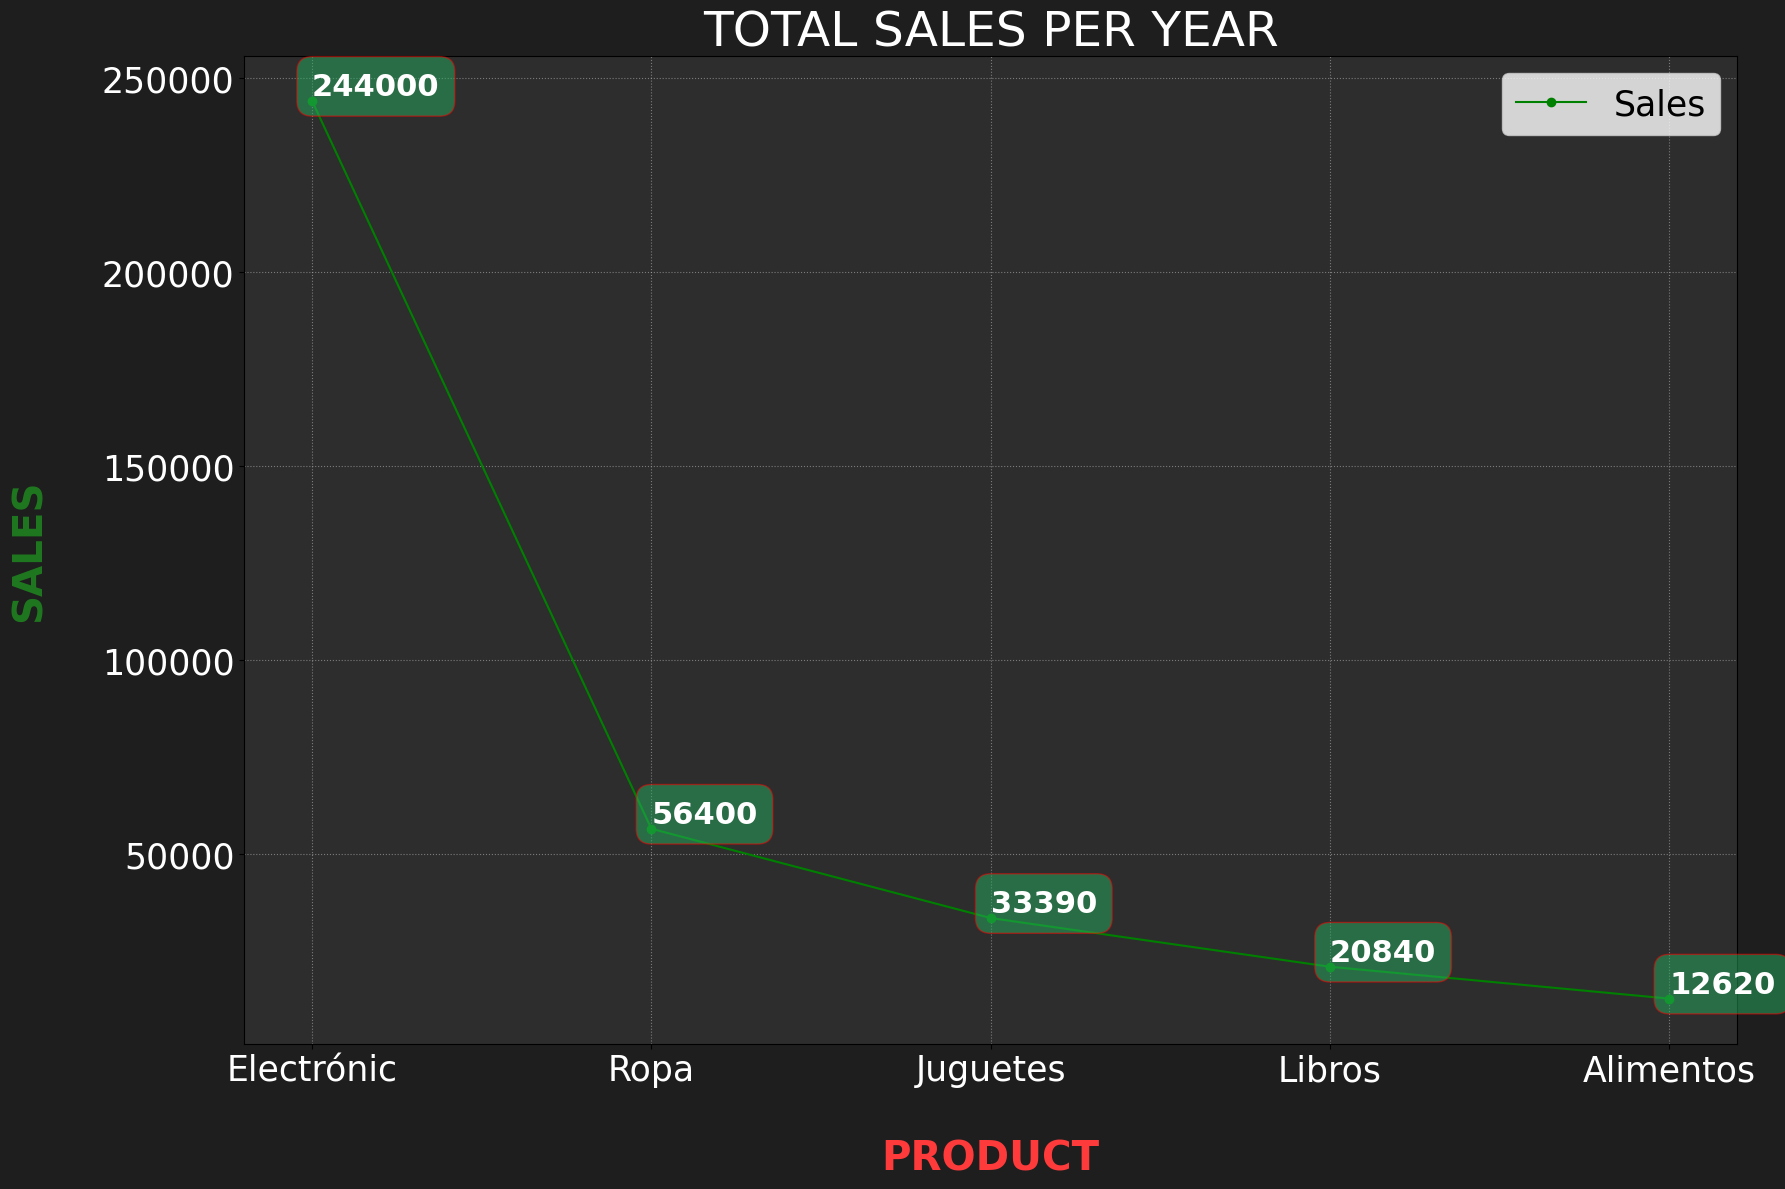

In [434]:
fig, ax = plt.subplots(figsize = (18,12))
fig.set_facecolor("#1e1e1e")
ax.set_facecolor("#2d2d2d")


plt.plot(df_product_sales['Product'], df_product_sales['Total'], label = "Sales", c = "g", marker = 'o')


for i, value in enumerate (df_product_sales['Total']):
    ax.text(df_product_sales['Product'].iloc[i], value + 1, str(value),
            ha = "left", va = "bottom", fontsize = 22, weight = "bold", color ="white", 
           bbox = dict(facecolor='#27ae60', alpha = 0.5 ,edgecolor = "red", boxstyle='round,pad=0.5'))


plt.title("TOTAL SALES PER YEAR", color = "White", fontsize = 35)
plt.xlabel("\nPRODUCT", c ="#FF3A3A", weight = "bold",  fontsize = 29)
plt.xticks(c = "white", fontsize = 25)
plt.ylabel("SALES\n", c = "#1E781E", weight ="bold", fontsize = 29)
plt.yticks(c = "white", fontsize = 25)
plt.grid(True, linestyle= ':', alpha = 0.6)
plt.legend(fontsize = 25)
plt.tight_layout()

## 2. Although December shows high sales activity, total sales still falls short of our annual peak-performance month. To bridge this gap, a strategic investment in a specialized marketing team is recommended. This team should focus on customer acquisition strategies and seasonal promotions to maximize sales during the holiday period.

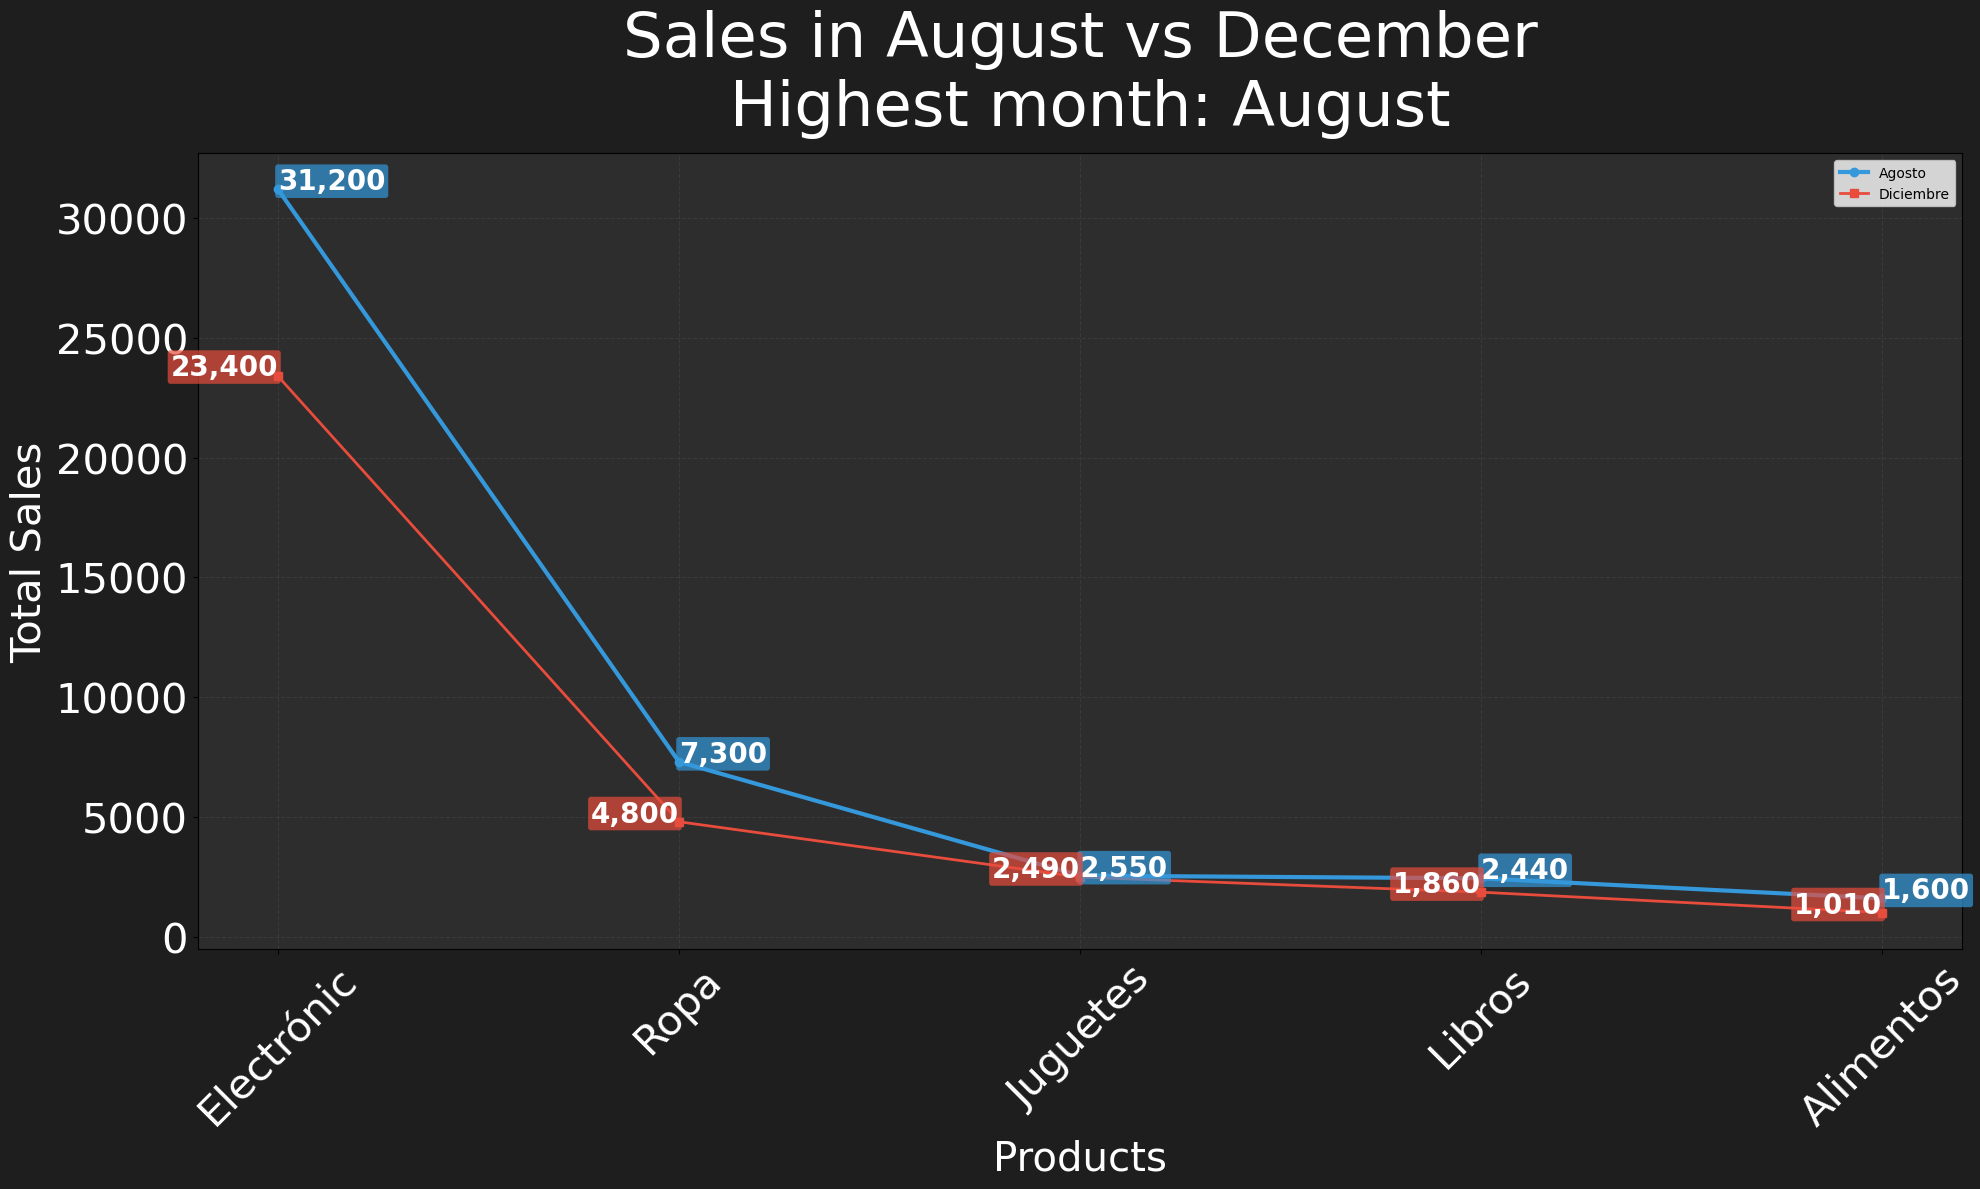

In [498]:

data_aug = total_august.reset_index(level=0, drop=True)
data_dec = total_december.reset_index(level=0, drop=True)

# 2. Configurar la figura
fig, ax = plt.subplots(figsize=(20, 12))
fig.set_facecolor('#1e1e1e') 
ax.set_facecolor('#2d2d2d')  

# 3. Graficar ambas líneas
ax.plot(data_aug.index, data_aug.values, label="Agosto", marker='o', c='#3498db', linewidth=3)
ax.plot(data_dec.index, data_dec.values, label="Diciembre", marker='s', c='#e74c3c', linewidth=2)

def add_labels(data, bubble_color):
   for i, (product, value) in enumerate(data.items()):
       ax.text(i, value + (value * 0.0002), f"{value:,.0f}", 
               ha='left'  , va='baseline'  , color='white', fontweight='bold', fontsize = 20,
               bbox=dict(facecolor=bubble_color, alpha=0.7, edgecolor='none', boxstyle='round,pad=0.1'))

add_labels(data_aug, '#3498db')



def add_labels2 (data, bubble_color):
    for i, (product, value) in enumerate (data.items()):
        ax.text(i, value + (value* 0.002), f"{value:,.0f}",
                ha = 'right', va = 'baseline', color = 'white', fontweight = 'bold', fontsize = 20,
                bbox = dict(facecolor = bubble_color, alpha = 0.7, edgecolor = 'none', boxstyle = 'round,pad=0.1'))
        
add_labels2(data_dec, '#e74c3c')

# 5. Personalización estética
plt.title(f"Sales in August vs December\n Highest month: {highest_month}", 
          color='white', fontsize=45, pad=20)
plt.xlabel("Products", color='white', fontsize = 29)
plt.xticks(rotation=45, color='white', fontsize = 30)
plt.ylabel("Total Sales", color='white', fontsize = 30)
plt.yticks(color='white', fontsize = 30)
plt.grid(True, linestyle='--', alpha=0.1)

# Leyenda con texto blanco
leg = plt.legend()
for text in leg.get_texts():
    text.set_color("black") # O "white" dependiendo de tu preferencia

plt.tight_layout()
plt.show()

## 3. The "Alimentos" category consistently reports the lowest sales. Given its low market demand and the inherent risk of inventory spoilage (due to perishability), we should evaluate a phased exit strategy or a significant reduction in stock levels to optimize capital allocation.

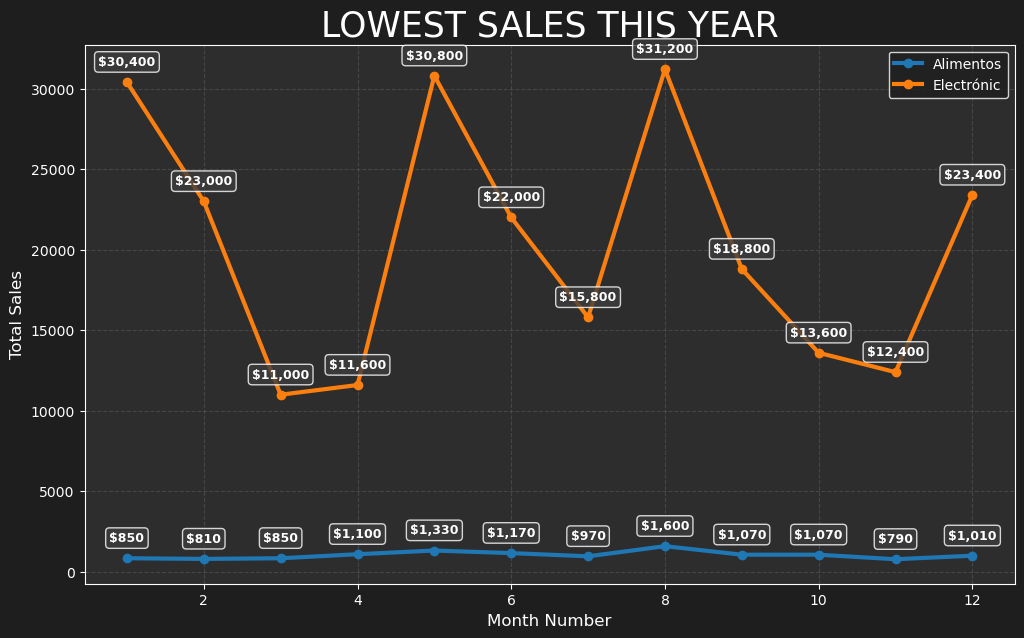

In [772]:
#Sort data for the highest and the lowest products
data1 = ["Electrónic", "Alimentos"]
months  = df_combined[df_combined["Product"].isin(data1)].groupby([df_combined["Date"].dt.month, "Product"])["Total"].sum().unstack()


fig, axe = plt.subplots(figsize = (12,7))

fig.set_facecolor('#1e1e1e')
axe.set_facecolor('#2d2d2d')

months.plot(kind='line', ax=axe, marker='o', linewidth=3)

for products in months.columns:
    for x, y in zip(months.index, months[products]):
        # Solo graficamos si el valor no es nulo (NaN)
        if pd.notnull(y):
            axe.annotate(
                f'${y:,.0f}',           # Texto: Formato moneda sin decimales
                (x, y),                 # Coordenada (x, y) del punto
                textcoords="offset points", 
                xytext=(0, 12),         # Desplazamiento: 12 puntos hacia ARRIBA del punto
                ha='center',            # Alineación horizontal al centro
                fontsize=9,
                color='white',          # Color del texto
                fontweight='bold',
                bbox=dict(              # Esto crea la "Burbuja" (cuadro de texto)
                    boxstyle='round,pad=0.3', 
                    fc='#3d3d3d',       # Color de fondo de la burbuja
                    ec='white',         # Color del borde de la burbuja
                    alpha=0.8           # Transparencia
                )
            )



plt.title("LOWEST SALES THIS YEAR", c= "white", fontsize = 25)
plt.xlabel("Month Number", color='white', fontsize=12)
plt.ylabel("Total Sales", color='white', fontsize=12)


axe.tick_params(colors = 'white')
for spine in axe.spines.values():
    spine.set_color('white')

#Configure legends
legend = axe.legend(facecolor='#1e1e1e', edgecolor='white', labelcolor='white')
axe.grid(color='gray', linestyle='--', alpha=0.3)


## 4. Analysis confirms a strong correlation between bi-weekly pay cycles and consumer behavior, with a 15.53% sales uplift on paydays. This indicates that customer liquidity is a primary driver of sales. To capitalize on this, we must ensure peak inventory availability 48 hours prior to paydays and schedule full staff coverage to handle the increased transaction volume.

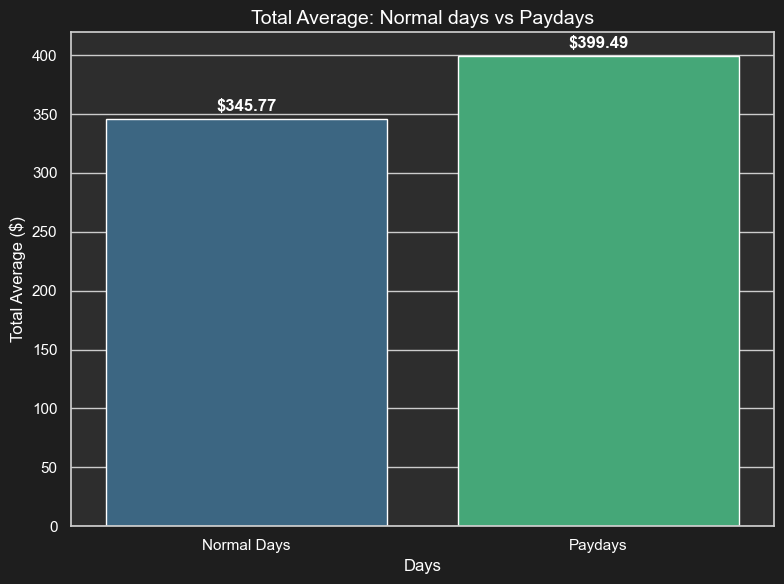

In [857]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

fig.set_facecolor('#1e1e1e')
ax.set_facecolor("#2d2d2d")

ax = sns.barplot(x= comparative.index, y=comparative.values, hue=comparative.index, palette="viridis", legend= False)

plt.xticks(ticks=[0, 1], labels=['Normal Days', 'Paydays'], color ="white")
plt.yticks(color ="white")
plt.title('Total Average: Normal days vs Paydays', fontsize=14, color = "white")
plt.ylabel('Total Average ($)', color = "white")
plt.xlabel('Days', color = "white")

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}',  (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=12, fontweight='bold', color = "white")
plt.tight_layout()
plt.show()